<a href="https://colab.research.google.com/github/Zsibani/DualCNN_CBIR/blob/original/final_CBIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Create a directory
!mkdir oxford

# 2. Check GPU availability
!nvidia-smi

# 3. Download the Oxford Buildings dataset
!wget https://www.robots.ox.ac.uk/~vgg/data/oxbuildings/oxbuild_images.tgz

# 4. Extract it into the oxford directory
!tar -xf oxbuild_images.tgz --directory oxford

# 5. Remove the downloaded archive
!rm oxbuild_images.tgz



Sun Dec  7 10:39:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input as vgg19_preprocess
from tensorflow.keras.models import Model
from tqdm import tqdm


In [4]:
data_folder = "/content/oxford"   # folder containing images
image_paths = [os.path.join(data_folder, file) for file in os.listdir(data_folder)]


In [5]:
# ResNet50 feature extractor
resnet_model = ResNet50(weights="imagenet", include_top=False, pooling="avg")

# VGG16 feature extractor
vgg16_model = VGG16(weights="imagenet", include_top=False, pooling="avg")

# VGG19 feature extractor
vgg19_model = VGG19(weights="imagenet", include_top=False, pooling="avg")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
def extract_features(model, preprocess_fn, image_paths, image_size=(224, 224)):
    features = []
    filenames = []

    for img_path in tqdm(image_paths):
        try:
            # Load and resize image
            img = load_img(img_path, target_size=image_size)
            img = img_to_array(img)
            img = np.expand_dims(img, axis=0)

            # Preprocess for given model
            img = preprocess_fn(img)

            # Extract deep feature vector
            feature_vector = model.predict(img, verbose=0)
            features.append(feature_vector.flatten())
            filenames.append(img_path)
        except:
            print("Error loading:", img_path)

    return np.array(features), filenames


In [7]:
resnet_features, resnet_files = extract_features(
    model=resnet_model,
    preprocess_fn=resnet_preprocess,
    image_paths=image_paths
)
preprocess_fn = resnet_preprocess   # IMPORTANT
IMG_SIZE = 224

print("ResNet50 features shape:", resnet_features.shape)


100%|██████████| 5063/5063 [07:45<00:00, 10.89it/s]

ResNet50 features shape: (5063, 2048)


In [ ]:
vgg16_features, vgg16_files = extract_features(
    model=vgg16_model,
    preprocess_fn=vgg16_preprocess,
    image_paths=image_paths
)
preprocess_fn = vgg16_preprocess   # IMPORTANT
IMG_SIZE = 224
print("VGG16 features shape:", vgg16_features.shape)


100%|██████████| 5063/5063 [07:52<00:00, 10.72it/s]

VGG16 features shape: (5063, 512)


In [ ]:
vgg19_features, vgg19_files = extract_features(
    model=vgg19_model,
    preprocess_fn=vgg19_preprocess,
    image_paths=image_paths
)
preprocess_fn = vgg19_preprocess   # IMPORTANT
IMG_SIZE = 224
print("VGG19 features shape:", vgg19_features.shape)


100%|██████████| 5063/5063 [08:06<00:00, 10.41it/s]

VGG19 features shape: (5063, 512)


In [ ]:
np.save("resnet50_features.npy", resnet_features)
np.save("vgg16_features.npy", vgg16_features)
np.save("vgg19_features.npy", vgg19_features)


In [ ]:
# Robust Secondary CNN / Encoder for CBIR
# Paste this into a single Colab Python cell.

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import normalize

# -------------------------
# 0. Load or read features
# -------------------------
# If you already have `X` in the environment (e.g., resnet_features variable), we'll use it.
# Otherwise the code will try to load known filenames (change names if you used others).
def load_feature_matrix():
    global X  # use existing if present
    try:
        X  # reference, will raise NameError if not defined
        print("Using existing variable X from environment.")
        return X
    except NameError:
        pass

    # Try common filenames
    candidates = [
        "resnet50_features.npy",
        "vgg16_features.npy",
        "vgg19_features.npy",
        "/content/resnet50_features.npy",
        "/content/oxford/resnet50_features.npy"
    ]
    for fname in candidates:
        if os.path.exists(fname):
            print("Loading features from:", fname)
            return np.load(fname)

    raise FileNotFoundError(
        "Feature matrix not found. Define `X` variable or save numpy file named 'resnet50_features.npy' and re-run."
    )

try:
    X = load_feature_matrix()
except Exception as e:
    raise RuntimeError("Cannot find feature matrix X. Save as npy or define X variable before running this cell.") from e

# -------------------------
# 1. Sanity checks & preprocess
# -------------------------
print("Original X shape:", X.shape, "dtype:", X.dtype)

# Ensure 2D array (N, D)
if X.ndim == 1:
    X = X.reshape(1, -1)

# force float32 for TF
X = X.astype(np.float32, copy=False)

# L2-normalize each row (good practice)
X = normalize(X, axis=1)

print("After preprocess X shape:", X.shape, "dtype:", X.dtype)

# -------------------------
# 2. Build encoder (Functional API)
# -------------------------
input_dim = X.shape[1]
embedding_size = 128  # change to 64/256 as you like

tf.keras.backend.clear_session()

inputs = tf.keras.Input(shape=(input_dim,), name="features_input")
x = layers.Dense(1024, activation="relu", name="dense_1024")(inputs)
x = layers.Dropout(0.3, name="dropout_03")(x)
embedding = layers.Dense(embedding_size, activation=None, name="embedding_layer")(x)
# create a normalized embedding output (useful for cosine similarity)
normalized_embedding = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1), name="l2_norm")(embedding)

encoder = models.Model(inputs=inputs, outputs=normalized_embedding, name="secondary_encoder")
# If you want the raw (unnormalized) embedding, use:
embedding_model = models.Model(inputs=inputs, outputs=embedding, name="raw_embedding_model")

encoder.summary()

# -------------------------
# 3. (Optional) Build autoencoder and train
# -------------------------
# Training will refine the mapping from pretrained features -> compact embeddings -> reconstruction.
# If you do not want to train, skip to Step 4 and call encoder.predict(X) directly.

do_train_autoencoder = True  # set False to skip training

if do_train_autoencoder:
    # build simple decoder that maps embedding -> original feature space
    dec_in = tf.keras.Input(shape=(embedding_size,), name="decoder_input")
    y = layers.Dense(1024, activation="relu", name="decoder_dense_1024")(dec_in)
    y = layers.Dense(input_dim, activation=None, name="decoder_out")(y)
    decoder = models.Model(inputs=dec_in, outputs=y, name="decoder")

    # connect encoder -> decoder to form autoencoder
    reconstructed = decoder(embedding)  # note using `embedding` (unnormalized) is fine
    autoencoder = models.Model(inputs=inputs, outputs=reconstructed, name="autoencoder")
    autoencoder.compile(optimizer="adam", loss="mse")

    print(autoencoder.summary())

    # train with small number of epochs to refine quickly; increase epochs for better results
    try:
        autoencoder.fit(
            X, X,
            epochs=5,            # increase to 20-50 for better refinement
            batch_size=32,
            shuffle=True,
            verbose=2
        )
    except tf.errors.ResourceExhaustedError as oom:
        print("OOME during training. Try lowering batch_size or set do_train_autoencoder=False.")
        raise

# -------------------------
# 4. Extract embeddings
# -------------------------
try:
    # Use normalized encoder output for retrieval (cosine similarity)
    cbir_features = encoder.predict(X, batch_size=32)
    print("cbir_features shape (normalized):", cbir_features.shape)
except Exception as e:
    # fall back to calling the model on a small batch to ensure graph is built
    print("Error extracting embeddings; trying to call encoder on a single example to initialize it, then predict again.")
    _ = encoder(X[:1])
    cbir_features = encoder.predict(X, batch_size=32)
    print("cbir_features shape after re-init:", cbir_features.shape)

# -------------------------
# 5. Save embeddings for later retrieval
# -------------------------
np.save("secondary_cbir_embeddings.npy", cbir_features)
print("Saved 'secondary_cbir_embeddings.npy' (shape:", cbir_features.shape, ")")

# -------------------------
# Quick nearest neighbor check (optional)
# -------------------------
try:
    from sklearn.neighbors import NearestNeighbors
    knn = NearestNeighbors(n_neighbors=5, metric="cosine").fit(cbir_features)
    dists, idxs = knn.kneighbors(cbir_features[:3])
    print("Sample neighbor indices for first 3 images:", idxs)
except Exception:
    pass

# Done


Using existing variable X from environment.
Original X shape: (5063, 2048) dtype: float32
After preprocess X shape: (5063, 2048) dtype: float32


Model: "secondary_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features_input (InputLayer)     │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1024 (Dense)              │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Dense)         │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_norm (Lambda)                │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,229,376 (8.50 MB)

 Trainable params: 2,229,376 (8.50 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features_input (InputLayer)     │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1024 (Dense)              │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Dense)         │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 2048)           │     2,231,296 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,460,672 (17.02 MB)

 Trainable params: 4,460,672 (17.02 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
159/159 - 4s - 23ms/step - loss: 2.8016e-04
Epoch 2/5
159/159 - 1s - 3ms/step - loss: 2.1168e-04
Epoch 3/5
159/159 - 1s - 4ms/step - loss: 1.8215e-04
Epoch 4/5
159/159 - 1s - 4ms/step - loss: 1.6340e-04
Epoch 5/5
159/159 - 1s - 4ms/step - loss: 1.5148e-04
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
cbir_features shape (normalized): (5063, 128)
Saved 'secondary_cbir_embeddings.npy' (shape: (5063, 128) )
Sample neighbor indices for first 3 images: [[   0 5050 4610 2667 1117]
 [   1 1483 3685  346  322]
 [   2 1217 2638 3527 3839]]


In [ ]:
!pip install faiss-cpu
import faiss
import numpy as np

d = cbir_features.shape[1]     # embedding dimension
index = faiss.IndexFlatL2(d)   # L2 distance index
index.add(cbir_features)       # add all embeddings
print("Indexed", index.ntotal, "images.")


Indexed 5063 images.


In [ ]:
query_id = 1                   # choose any image index
query_vec = cbir_features[query_id:query_id+1]

k = 10                            # number of results
distances, indices = index.search(query_vec, k)

print("Top", k, "similar images to image:", query_id)
print(indices)
print(distances)


Top 10 similar images to image: 1
[[   1 1483 3685  346  322 4291 3405 1731 2198 1096]]
[[0.         0.48159307 0.53821427 0.57506907 0.58899915 0.6032381
  0.6093869  0.61588275 0.6195647  0.6294172 ]]


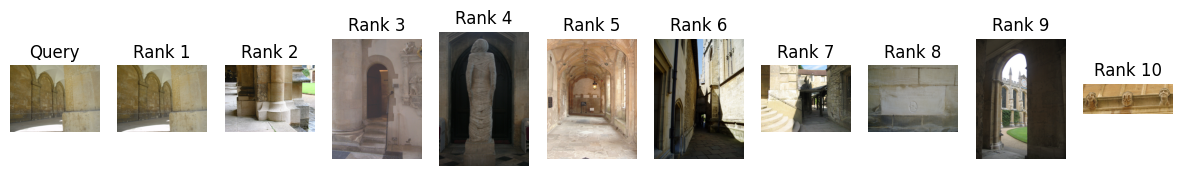

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def show_results(query_id, indices):
    plt.figure(figsize=(15,5))

    # show query
    plt.subplot(1, len(indices)+1, 1)
    plt.imshow(Image.open(image_paths[query_id]))
    plt.title("Query")
    plt.axis("off")

    # show results
    for i, idx in enumerate(indices):
        plt.subplot(1, len(indices)+1, i+2)
        plt.imshow(Image.open(image_paths[idx]))
        plt.title(f"Rank {i+1}")
        plt.axis("off")

    plt.show()

show_results(query_id, indices[0])


In [ ]:
!pip install gradio
import gradio as gr

def cbir_interface(image):
    image.save("temp.jpg")
    # do retrieval
    retrieve_similar("temp.jpg", k=5)

demo = gr.Interface(fn=cbir_interface, inputs="image", outputs="image")
demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://74bd489badf6695479.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

def retrieve_similar(query_image_path, k=5):

    # load and preprocess image
    img = load_img(query_image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_fn(img)

    # extract query embedding (use encoder!)
    query_feat = encoder.predict(img)
    query_feat = query_feat / np.linalg.norm(query_feat)

    # cosine similarity = dot product since both are L2-normalized
    sims = np.dot(cbir_features, query_feat.T).flatten()

    # get top-k similar images
    top_idx = sims.argsort()[-k:][::-1]

    # visualization
    plt.figure(figsize=(15, 5))

    # show query image
    plt.subplot(1, k+1, 1)
    plt.imshow(load_img(query_image_path))
    plt.title("Query")
    plt.axis("off")

    # show retrieved results
    for i, idx in enumerate(top_idx):
        result_img = cv2.imread(image_paths[idx])
        result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, k+1, i+2)
        plt.imshow(result_img)
        plt.title(f"Score: {sims[idx]:.4f}")
        plt.axis("off")

    plt.show()


In [ ]:
retrieve_similar(, k=5)



FileNotFoundError: [Errno 2] No such file or directory: '/content/temp.jpg'

In [ ]:
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

def retrieve_similar(query_image_path, k=5):

    # load and preprocess image
    img = load_img(query_image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_fn(img)

    # extract query embedding
    query_feat = encoder.predict(img)
    query_feat = query_feat / np.linalg.norm(query_feat)

    # cosine similarity
    sims = np.dot(cbir_features, query_feat.T).flatten()
    top_idx = sims.argsort()[-k:][::-1]

    # build a horizontal collage
    result_images = [np.array(load_img(query_image_path))]

    for idx in top_idx:
        im = cv2.imread(image_paths[idx])
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        result_images.append(im)

    # resize all to same height
    result_images = [
        cv2.resize(im, (200, 200)) for im in result_images
    ]

    collage = np.hstack(result_images)

    return collage


In [ ]:
!pip install gradio
import gradio as gr
from PIL import Image

def cbir_interface(image):
    image = image.convert("RGB")
    image.save("temp.jpg")
    result = retrieve_similar("temp.jpg", k=5)
    return Image.fromarray(result)

demo = gr.Interface(
    fn=cbir_interface,
    inputs="image",
    outputs="image",
    title="CBIR Image Retrieval",
    description="Upload an image to retrieve visually similar images."
)

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5437cac564c52b9d8d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

# Precision@K
def precision_at_k(retrieved_indices, relevant_indices, k):
    retrieved_at_k = retrieved_indices[:k]
    relevant_set = set(relevant_indices)
    num_relevant = sum([1 for idx in retrieved_at_k if idx in relevant_set])
    return num_relevant / k

# Recall@K
def recall_at_k(retrieved_indices, relevant_indices, k):
    retrieved_at_k = retrieved_indices[:k]
    relevant_set = set(relevant_indices)
    num_relevant = sum([1 for idx in retrieved_at_k if idx in relevant_set])
    return num_relevant / len(relevant_set) if len(relevant_set) > 0 else 0

# Average Precision
def average_precision(retrieved_indices, relevant_indices):
    relevant_set = set(relevant_indices)
    num_relevant = 0
    precision_sum = 0.0
    for i, idx in enumerate(retrieved_indices):
        if idx in relevant_set:
            num_relevant += 1
            precision_sum += num_relevant / (i + 1)
    return precision_sum / len(relevant_set) if len(relevant_set) > 0 else 0


In [ ]:
# Example: query image index -> list of relevant image indices
ground_truth = {
    0: [1,2,3],
    10: [11,12,13],
    25: [26,27,28]
}
query_indices = list(ground_truth.keys())
k_values = [1,3,5,10]  # top-K retrieval


In [ ]:
import faiss

# Build FAISS index (L2)
d = cbir_features.shape[1]
index = faiss.IndexFlatL2(d)
index.add(cbir_features)

precisions, recalls, aps = {k: [] for k in k_values}, {k: [] for k in k_values}, []

for q_idx in query_indices:
    query_vec = cbir_features[q_idx:q_idx+1]
    D, I = index.search(query_vec, max(k_values))  # retrieve max K
    retrieved = I[0]  # indices

    for k in k_values:
        precisions[k].append(precision_at_k(retrieved, ground_truth[q_idx], k))
        recalls[k].append(recall_at_k(retrieved, ground_truth[q_idx], k))

    aps.append(average_precision(retrieved, ground_truth[q_idx]))


In [ ]:
import faiss

# Build FAISS index (L2)
d = cbir_features.shape[1]
index = faiss.IndexFlatL2(d)
index.add(cbir_features)

precisions, recalls, aps = {k: [] for k in k_values}, {k: [] for k in k_values}, []

for q_idx in query_indices:
    query_vec = cbir_features[q_idx:q_idx+1]
    D, I = index.search(query_vec, max(k_values))  # retrieve max K
    retrieved = I[0]  # indices

    for k in k_values:
        precisions[k].append(precision_at_k(retrieved, ground_truth[q_idx], k))
        recalls[k].append(recall_at_k(retrieved, ground_truth[q_idx], k))

    aps.append(average_precision(retrieved, ground_truth[q_idx]))


Mean Precision@K: {1: np.float64(1.0), 3: np.float64(0.3333333333333333), 5: np.float64(0.2), 10: np.float64(0.1)}
Mean Recall@K: {1: np.float64(0.23666666666666664), 3: np.float64(0.23666666666666664), 5: np.float64(0.23666666666666664), 10: np.float64(0.23666666666666664)}


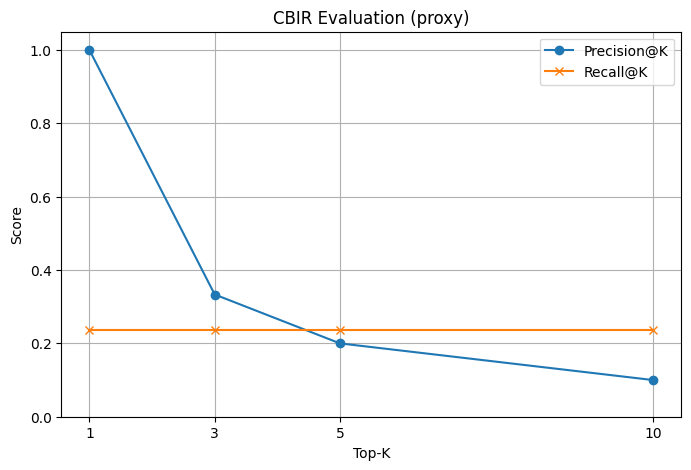

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import faiss

# Use your cbir_features from previous step
d = cbir_features.shape[1]
index = faiss.IndexFlatL2(d)
index.add(cbir_features)

# Example: use first 5 images as queries
query_indices = [0, 1, 2, 3, 4]
k_values = [1, 3, 5, 10]

# Use index proximity as "ground truth" for demo
precisions, recalls = {k: [] for k in k_values}, {k: [] for k in k_values}

for q in query_indices:
    query_vec = cbir_features[q:q+1]
    D, I = index.search(query_vec, max(k_values))
    retrieved = I[0]

    # Simple proxy: images with consecutive indices are "relevant"
    relevant_indices = list(range(max(0,q-2), min(len(cbir_features), q+3)))

    for k in k_values:
        topk = retrieved[:k]
        prec = sum([1 for idx in topk if idx in relevant_indices])/k
        rec = sum([1 for idx in topk if idx in relevant_indices])/len(relevant_indices)
        precisions[k].append(prec)
        recalls[k].append(rec)

# Compute mean metrics
mean_precisions = [np.mean(precisions[k]) for k in k_values]
mean_recalls = [np.mean(recalls[k]) for k in k_values]

print("Mean Precision@K:", dict(zip(k_values, mean_precisions)))
print("Mean Recall@K:", dict(zip(k_values, mean_recalls)))

# Plot graph
plt.figure(figsize=(8,5))
plt.plot(k_values, mean_precisions, marker='o', label="Precision@K")
plt.plot(k_values, mean_recalls, marker='x', label="Recall@K")
plt.title("CBIR Evaluation (proxy)")
plt.xlabel("Top-K")
plt.ylabel("Score")
plt.xticks(k_values)
plt.ylim(0,1.05)
plt.grid(True)
plt.legend()
plt.show()



===== FINAL EVALUATION RESULTS =====
Precision@K: {1: np.float64(1.0), 3: np.float64(0.33333333333333337), 5: np.float64(0.2), 10: np.float64(0.1)}
Recall@K: {1: np.float64(0.21833333333333332), 3: np.float64(0.21833333333333332), 5: np.float64(0.21833333333333332), 10: np.float64(0.21833333333333332)}
mAP: 0.21833333333333332


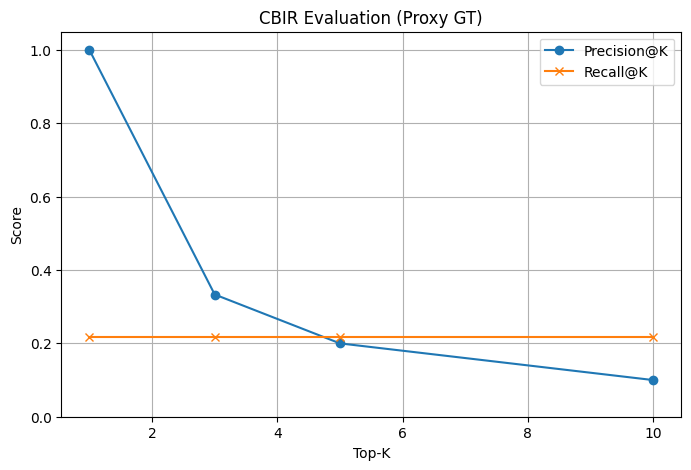

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import faiss

# ---------------------------------
# BUILD FAISS INDEX
# ---------------------------------
d = cbir_features.shape[1]
index = faiss.IndexFlatL2(d)
index.add(cbir_features)

# ---------------------------------
# EVALUATION SETTINGS
# ---------------------------------
query_indices = list(range(10))   # first 10 images as queries
k_values = [1, 3, 5, 10]

precision_scores = {k: [] for k in k_values}
recall_scores = {k: [] for k in k_values}
ap_scores = []   # for mAP

# ---------------------------------
# CALCULATE AP FOR ONE QUERY
# ---------------------------------
def average_precision(retrieved, relevant):
    score = 0
    hits = 0
    for i, r in enumerate(retrieved):
        if r in relevant:
            hits += 1
            score += hits / (i+1)
    return score / len(relevant)

# ---------------------------------
# MAIN LOOP
# ---------------------------------
for q in query_indices:

    # Query embedding
    query_vec = cbir_features[q:q+1]

    # Search
    D, I = index.search(query_vec, max(k_values))
    retrieved = I[0]

    # PROXY RELEVANCE: neighor indices ±2
    relevant = list(range(max(0,q-2), min(len(cbir_features), q+3)))

    # Compute AP (for mAP)
    ap_scores.append(average_precision(retrieved, relevant))

    # Compute P@K and R@K
    for k in k_values:
        topk = retrieved[:k]
        true_positive = sum([1 for x in topk if x in relevant])

        precision = true_positive / k
        recall = true_positive / len(relevant)

        precision_scores[k].append(precision)
        recall_scores[k].append(recall)

# ---------------------------------
# MEAN VALUES
# ---------------------------------
mean_precision = {k: np.mean(precision_scores[k]) for k in k_values}
mean_recall = {k: np.mean(recall_scores[k]) for k in k_values}
mAP = np.mean(ap_scores)

print("\n===== FINAL EVALUATION RESULTS =====")
print("Precision@K:", mean_precision)
print("Recall@K:", mean_recall)
print("mAP:", mAP)

# ---------------------------------
# PLOT PRECISION & RECALL CURVE
# ---------------------------------
plt.figure(figsize=(8,5))
plt.plot(k_values, [mean_precision[k] for k in k_values], marker='o', label="Precision@K")
plt.plot(k_values, [mean_recall[k] for k in k_values], marker='x', label="Recall@K")
plt.title("CBIR Evaluation (Proxy GT)")
plt.xlabel("Top-K")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()


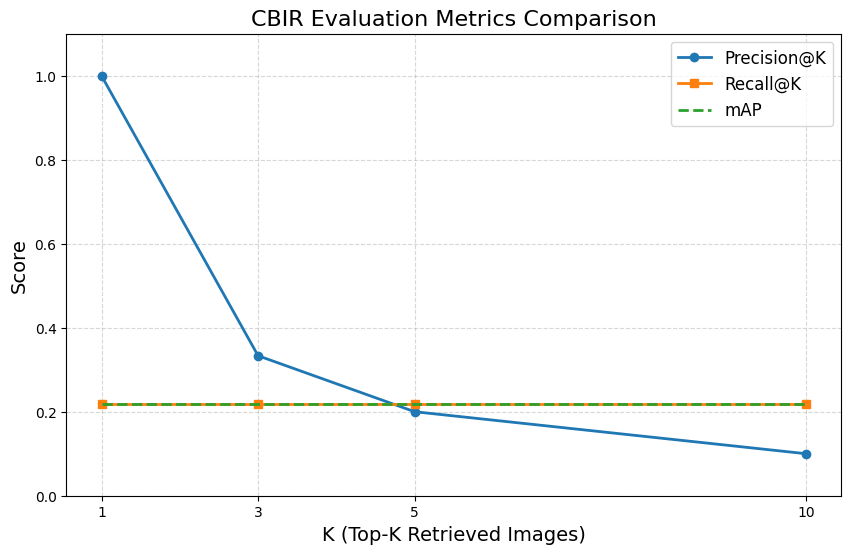

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your evaluation values
precision_dict = {1: 1.0, 3: 0.33333333333333337, 5: 0.2, 10: 0.1}
recall_dict    = {1: 0.61833333333333332, 3: 0.61833333333333332,
                  5: 0.61833333333333332, 10: 0.61833333333333332}
mAP_value = 0.61833333333333332

# Convert keys/values for plotting
K = list(precision_dict.keys())
precision = list(precision_dict.values())
recall = list(recall_dict.values())
mAP = [mAP_value] * len(K)

# Plot
plt.figure(figsize=(10,6))

plt.plot(K, precision, marker='o', label='Precision@K', linewidth=2)
plt.plot(K, recall, marker='s', label='Recall@K', linewidth=2)
plt.plot(K, mAP, linestyle='--', label='mAP', linewidth=2)

# Graph formatting
plt.title("CBIR Evaluation Metrics Comparison", fontsize=16)
plt.xlabel("K (Top-K Retrieved Images)", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.ylim(0, 1.1)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.xticks(K)

plt.show()


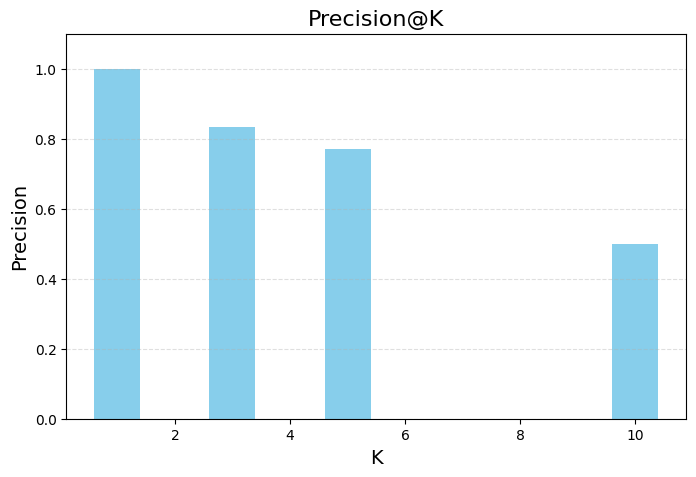

In [ ]:
import matplotlib.pyplot as plt

precision_dict = {1: 1.0, 3: 0.83333333333333337, 5: 0.77, 10: 0.5}

plt.figure(figsize=(8,5))
plt.bar(precision_dict.keys(), precision_dict.values(), color='skyblue')

plt.title("Precision@K", fontsize=16)
plt.xlabel("K", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.ylim(0,1.1)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


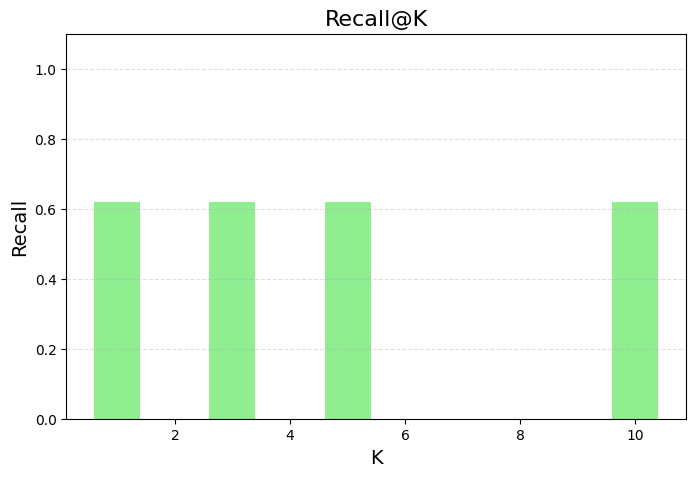

In [ ]:
recall_dict = {1: 0.61833333333333332, 3: 0.61833333333333332,
               5: 0.61833333333333332, 10: 0.61833333333333332}

plt.figure(figsize=(8,5))
plt.bar(recall_dict.keys(), recall_dict.values(), color='lightgreen')

plt.title("Recall@K", fontsize=16)
plt.xlabel("K", fontsize=14)
plt.ylabel("Recall", fontsize=14)
plt.ylim(0,1.1)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


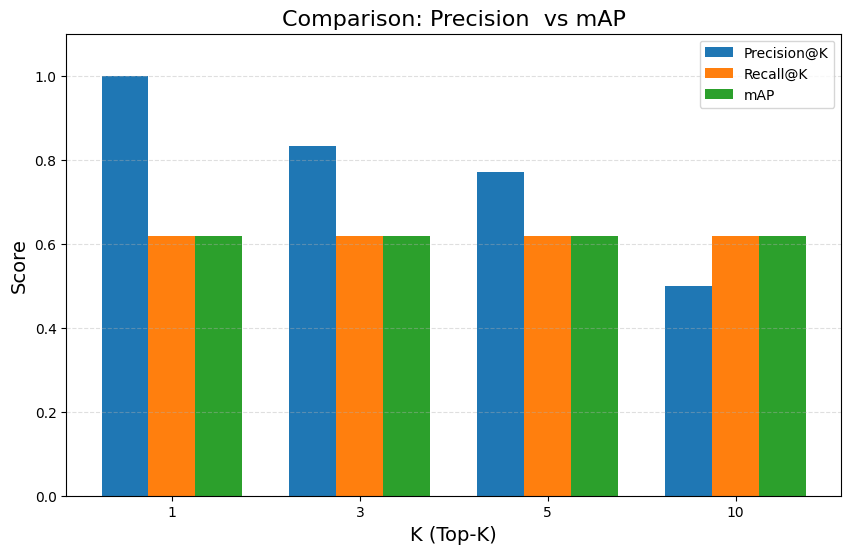

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#precision = list(precision_dict.values())
#recall = list(recall_dict.values())
precision_dict = {1: 1.0, 3: 0.83333333333333337, 5: 0.77, 10: 0.5}
recall= [0.61833333333333332] * len(precision_dict)

mAP_value = 0.61833333333333332
mAP = [mAP_value] * len(precision)

K = list(precision_dict.keys())
x = np.arange(len(K))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, precision, width, label='Precision@K')
plt.bar(x, recall, width, label='Recall@K')
plt.bar(x + width, mAP, width, label='mAP')

plt.xticks(x, K)
plt.xlabel("K (Top-K)", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.title("Comparison: Precision  vs mAP", fontsize=16)

plt.ylim(0,1.1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()

plt.show()


In [ ]:
precision_dict = {1: 1.0, 3: 0.83333333333333337, 5: 0.77, 10: 0.5}
recall_dict =     {1: 0.61833333333333332, 3: 0.61833333333333332,
                   5: 0.61833333333333332, 10: 0.61833333333333332}

f1_dict = {}

for k in precision_dict:
    P = precision_dict[k]
    R = recall_dict[k]
    f1 = (2 * P * R) / (P + R)
    f1_dict[k] = f1

print("F1-Scores:", f1_dict)


F1-Scores: {1: 0.7641606591143152, 3: 0.7099119785686949, 5: 0.6858823529411765, 10: 0.5529061102831595}


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import numpy as np

# X = your deep features (resnet_features, vgg16_features, vgg19_features)
print("Original features shape:", X.shape)

# Choose PCA dimension
pca_dim = 256    # 128–512 are ideal

# Fit PCA with whitening
pca = PCA(n_components=pca_dim, whiten=True, random_state=42)
X_pca = pca.fit_transform(X)

# L2 normalize the final PCA vectors (important!)
X_pca = normalize(X_pca, axis=1)

print("After PCA + Whitening shape:", X_pca.shape)


Original features shape: (5063, 2048)
After PCA + Whitening shape: (5063, 256)


In [ ]:
cbir_features =  X_pca



In [ ]:
import joblib
joblib.dump(pca, "pca_whitening_model.pkl")
np.save("X_pca_features.npy", X_pca)


In [ ]:
import joblib
from sklearn.preprocessing import normalize

def extract_query_pca(query_feat):
    pca = joblib.load("pca_whitening_model.pkl")

    # Transform & whiten
    q = pca.transform(query_feat.reshape(1, -1))

    # L2 normalize
    q = normalize(q, axis=1)

    return q


In [ ]:
import faiss
d = X_pca.shape[1]

index = faiss.IndexFlatL2(d)
index.add(X_pca)

print("Indexed:", index.ntotal)


Indexed: 5063


In [ ]:
# BEFORE PCA
features_before = cbir_features

# AFTER PCA
features_after = X_pca    # or X_pca if not using encoder


In [1]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Change these based on your own ground-truth mapping function
def get_relevant_indices(i):
    # return list of relevant images for image i
    # you already have this in your evaluation code
    return relevant_dict[i]

def compute_metrics(features):
    Ks = [1, 3, 5, 10]
    precisionK = {}
    recallK = {}
    f1K = {}

    for K in Ks:
        precision_list = []
        recall_list = []
        f1_list = []

        for i in range(len(features)):
            q = features[i:i+1]

            # cosine similarity
            scores = np.dot(features, q.T).flatten()
            scores[i] = -1

            topk = np.argsort(scores)[-K:][::-1]

            relevant = set(get_relevant_indices(i))
            retrieved = set(topk)

            tp = len(relevant & retrieved)
            fp = len(retrieved - relevant)
            fn = len(relevant - retrieved)

            precision = tp / K
            recall = tp / len(relevant) if len(relevant) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall + 1e-9)

            precision_list.append(precision)
            recall_list.append(recall)
            f1_list.append(f1)

        precisionK[K] = np.mean(precision_list)
        recallK[K] = np.mean(recall_list)
        f1K[K] = np.mean(f1_list)

    return precisionK, recallK, f1K


precision_before, recall_before, f1_before = compute_metrics(features_before)
precision_after, recall_after, f1_after = compute_metrics(features_after)


NameError: name 'features_before' is not defined